# Improving GLIMPSE — alternative projection testing

GLIMPSE shows a person where they stand relative to a model's decision, and how much
that decision would change if you had fitted a slightly different — equally good —
model. All of that has to happen on a **flat 2-D picture**, which means GLIMPSE lives
or dies on its choice of projection.

Today that projection is **ECLIPSE**. This notebook asks whether that was the right
call, by putting ECLIPSE against **twelve alternatives** on **seven datasets**, and
then tries three concrete ways to make it better.

**What is in here**

| § | |
|---|---|
| 1 | What GLIMPSE actually *needs* from a projection (this is not a beauty contest) |
| 2 | The bare-minimum GLIMPSE, running |
| 3 | The thirteen contenders and what each can and cannot do |
| 4 | Head-to-head numbers on seven datasets |
| 5 | Pictures, on the datasets small enough to read |
| 6 | **"p(y\|x) comes from a Gaussian"** — what that means and what to do with it |
| 7 | Three candidate improvements to ECLIPSE, tested |
| 8 | Findings |

Everything runs from this folder alone. Nothing here reaches into the deployed tool.

## 0. Setup

In [1]:
import warnings, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "font.size": 10, "axes.facecolor": "white"})

import benchmark, metrics, projections as P, variants, viz, gaussian as G
from lab import fit_glimpse, EPS
from lab import LOADERS, DATASET_CHOICES, evaluate
from lab import rash_ceiling, build_S
from lab import disagreement

DATASETS = ["pima", "heloc", "cancer", "german", "heart", "spambase", "taiwan"]
print("datasets available:", [c["key"] for c in DATASET_CHOICES])

datasets available: ['pima', 'heloc', 'cancer', 'german', 'heart', 'spambase', 'taiwan']


## 1. What GLIMPSE needs from a projection

Most projection papers optimise for one thing: does the picture preserve neighbourhoods?
GLIMPSE cannot afford to care only about that, because the picture is not the product —
the picture is a **control surface**. Four things follow, and they are requirements,
not preferences.

**(a) It must place a person it has never seen.** Someone types their own numbers into
the form and expects a dot. A projection fitted transductively on a fixed table (t-SNE)
has no map for a new point. It is disqualified regardless of how good it looks.

**(b) It must run backwards.** Click a spot on the map and GLIMPSE has to say *which
person that is* — what glucose, what BMI. That is the inverse of the projection. No
inverse, no counterfactual panel.

**(c) Straight lines should stay straight.** If the projection is affine, the model's
decision boundary is a **line** on screen and the shortest path to flipping the decision
is a **straight arrow**. Bend the projection and both become curves that no longer mean
what the user thinks they mean.

**(d) It should know about the model.** Every method below except ECLIPSE builds its map
from the feature matrix `X` alone. GLIMPSE's picture is about a *decision*, so the
classifier and the set of equally-good alternative classifiers are legitimate inputs.

The rest of the notebook keeps score on both axes: the usual quality numbers, **and**
whether the method can do (a)–(d) at all.

### How we score
Two families of metric, deliberately kept apart.

**Readout metrics** — defined for every method, so they are the only fair cross-method
comparison. *If all you had was the picture, how much could you read off it?*

- `trust` — trustworthiness at k=10. Are on-screen neighbours real neighbours? **Higher better.**
- `sep2d` — 3-fold logistic AUC in the plane. Are the two outcome groups visibly apart? **Higher.**
- `score_read` — out-of-fold k-NN readout of the model's log-odds from position alone. **Higher.**
- `rash_read` — the same readout for *disagreement between equally-good models*. **Higher.**

**Inverse metrics** — only exist when the method has a decoder. *When the user clicks a
spot and GLIMPSE turns it back into a person, is that person faithful?*

- `recon` — mean \|x − decode(encode(x))\|. **Lower better.**
- `rt` — round-trip drift of the 2-D point relative to the spread. **Lower.**
- `score_inv`, `rash_inv` — Spearman between the real score/disagreement and the decoded point's. **Higher.**

A `NaN` in the inverse block is never a measurement failure. It means *this method
structurally cannot do this*, which is the finding.

Every lens is fitted on the **train half only**; every number is computed on the
**held-out half**. That is the setting the live tool runs in.

## 2. The bare-minimum GLIMPSE, running

The three objects GLIMPSE is built out of, in order:

1. a logistic model `p(y=1|x) = sigmoid(w·x + b)`;
2. the **Rashomon ellipsoid** — every parameter vector whose average log-loss is within
   `eps` of the fitted model's, approximated to second order. These are the models you
   had no statistical grounds to reject;
3. a **lens** — the 2-D plane the whole thing is drawn on.

`kappa2` in the table below is a hard ceiling, computed *before* any lens is fitted, on
how well **any** flat plane could ever show model disagreement. It matters later.

In [2]:
rows = []
for k in DATASETS:
    g = fit_glimpse(k, lens="eclipse")
    acc, auc = evaluate(g.model, g.X[g.idx_te], g.y[g.idx_te])
    rows.append({"dataset": k, "name": g.data.name, "n": g.data.n, "d": g.data.d,
                 "pos_rate": round(float(g.y.mean()), 3),
                 "missing_%": round(100 * float(g.data.missing_mask.mean()), 1),
                 "acc": round(acc, 3), "auc": round(auc, 3),
                 "kappa2": round(rash_ceiling(g.X[g.idx_tr], g.ell), 3),
                 "ECLIPSE auto-weights": g.lens.extra})
overview = pd.DataFrame(rows)
overview

,dataset,name,n,d,pos_rate,missing_%,acc,auc,kappa2,ECLIPSE auto-weights
0,pima,Pima,768,8,0.349,10.6,0.773,0.876,0.658,spread 0.44 / model 0.56
1,heloc,HELOC,9470,20,0.500,1.0,0.730,0.803,0.443,spread 0.69 / model 0.16 / disagreement 0.16
2,cancer,Breast cancer,569,30,0.373,0.0,0.974,0.993,0.962,spread 0.69 / model 0.31
3,german,German credit,1000,48,0.300,0.0,0.730,0.786,0.368,spread 0.62 / model 0.19 / disagreement 0.19
4,heart,Heart disease (Statlog),270,13,0.444,0.0,0.778,0.853,0.810,spread 0.06 / model 0.94
5,spambase,Spambase,4601,57,0.394,0.0,0.932,0.970,0.693,model 1.00
6,taiwan,Taiwan credit default,13272,23,0.500,0.0,0.682,0.730,0.742,spread 0.31 / model 0.34 / disagreement 0.34


The `ECLIPSE auto-weights` column is the lens telling you what it decided each dataset
needed. ECLIPSE's plane is the top-2 eigenvectors of a blend of four matrices —
**spread** (what PCA would use), **model** (the score direction), **disagreement**
(where equally-good models argue), **imputation** (where values had to be guessed) —
and the weights are chosen automatically on a validation split.

Read the column and the datasets sort themselves: `heart` spends almost everything on
the model direction; `heloc` and `german` keep most of the spread; `spambase` goes all
in on the model.

## 3. The thirteen contenders

In [3]:
methods = P.all_methods()
caps = pd.DataFrame([{"method": m.name, **m.caps.as_dict()} for m in methods])
caps["GLIMPSE-eligible"] = caps.out_of_sample & caps.invertible
caps.set_index("method")

,linear,supervised,invertible,out_of_sample,model_aware,GLIMPSE-eligible
method,,,,,,
PCA,True,False,True,True,False,True
Random,True,False,True,True,False,True
LDA,True,True,True,True,False,True
PLS,True,True,True,True,False,True
NCA,True,True,True,True,False,True
KernelPCA,False,False,True,True,False,True
Isomap,False,False,False,True,False,False
t-SNE,False,False,False,False,False,False
UMAP,False,False,True,True,False,True


Before a single number is computed, the capability table has already removed
candidates. **t-SNE** cannot place a new person. **Isomap** and **PaCMAP** can place
one but cannot run backwards, so they can never drive the counterfactual panel.
Only the `linear` methods give straight boundaries and straight recourse arrows.

`Random` is a control: a Gaussian random plane. Any method that cannot beat it has told
us nothing.

## 4. Head-to-head, seven datasets

In [ ]:
t0 = time.time()
results = benchmark.run_all(DATASETS, verbose=True)
print(f"\ntotal {time.time()-t0:.0f}s")
results.to_csv("results/benchmark_raw.csv", index=False)
results.head()


=== Pima  (n=768, d=8)  test acc 0.773 / AUC 0.876  kappa2 0.658 ===
  PCA          trust 0.835  sep2d 0.800  score 0.910  rash 0.471  (0.0s) 
  Random       trust 0.767  sep2d 0.737  score 0.778  rash 0.227  (0.0s) 
  LDA          trust 0.818  sep2d 0.860  score 0.990  rash 0.539  (0.0s) 
  PLS          trust 0.782  sep2d 0.853  score 0.986  rash 0.476  (0.0s) 
  NCA          trust 0.795  sep2d 0.863  score 0.988  rash 0.485  (0.2s) 
  KernelPCA    trust 0.776  sep2d 0.801  score 0.868  rash 0.469  (0.0s) 
  Isomap       trust 0.830  sep2d 0.766  score 0.872  rash 0.483  (0.0s) no inverse
  t-SNE        trust 0.916  sep2d 0.781  score 0.904  rash 0.600  (0.2s) in-sample only (refit); cannot place a new person


  UMAP         trust 0.860  sep2d 0.716  score 0.823  rash 0.439  (6.3s) 
  PaCMAP       trust 0.854  sep2d 0.738  score 0.799  rash 0.613  (0.2s) no inverse
  Autoencoder  trust 0.865  sep2d 0.756  score 0.865  rash 0.630  (1.6s) 


### 4.1 One table per metric

In [ ]:
for m, higher in [("trust", True), ("sep2d", True), ("score_read", True),
                  ("rash_read", True)]:
    t = benchmark.summarize(results, m)
    print(f"\n### {m} — {metrics.METRIC_HELP[m]}")
    print(t.to_string())


### trust — trustworthiness, k=10 — are on-screen neighbours real neighbours? (higher better)
dataset      cancer  german  heart  heloc   pima  spambase  taiwan   mean
method                                                                   
PCA           0.905   0.673  0.801  0.783  0.835     0.678   0.830  0.787
Random        0.757   0.623  0.701  0.684  0.768     0.606   0.657  0.685
LDA           0.832   0.649  0.794  0.766  0.818     0.670   0.808  0.762
PLS           0.860   0.594  0.797  0.755  0.782     0.678   0.800  0.752
NCA           0.773   0.665  0.765  0.748  0.794     0.648   0.831  0.746
KernelPCA     0.816   0.613  0.742  0.736  0.776     0.620   0.793  0.728
Isomap        0.909   0.688  0.805  0.785  0.830     0.682   0.843  0.792
t-SNE         0.929   0.858  0.877  0.932  0.906     0.853   0.948  0.900
UMAP          0.884   0.803  0.794  0.867  0.857     0.813   0.934  0.850
PaCMAP        0.894   0.777  0.803  0.869  0.852     0.789   0.919  0.843
Autoencoder   0.9

In [ ]:
print("INVERSE-ONLY METRICS  (NaN = the method has no decoder at all)\n")
for m in ["recon", "rt", "score_inv", "rash_inv"]:
    print(f"\n### {m} — {metrics.METRIC_HELP[m]}")
    print(benchmark.summarize(results, m).to_string())

INVERSE-ONLY METRICS  (NaN = the method has no decoder at all)


### recon — mean |x - decode(encode(x))| — decoder error (LOWER better)
dataset      cancer  german  heart  heloc   pima  spambase  taiwan   mean
method                                                                   
PCA           0.380   0.627  0.652  0.569  0.527     0.356   0.504  0.516
Random        0.697   0.681  0.750  0.686  0.642     0.418   0.614  0.641
LDA           0.502   0.640  0.677  0.616  0.555     0.364   0.532  0.555
PLS           0.455   0.659  0.667  0.600  0.558     0.367   0.568  0.553
NCA           0.590   0.668  0.720  0.649  0.575     0.408   0.520  0.590
KernelPCA     0.468   0.643  0.670  0.588  0.559     0.377   0.466  0.539
Isomap          NaN     NaN    NaN    NaN    NaN       NaN     NaN    NaN
t-SNE           NaN     NaN    NaN    NaN    NaN       NaN     NaN    NaN
UMAP          0.495   0.660  0.720  0.480  0.595     0.255   0.293  0.500
PaCMAP          NaN     NaN    NaN    NaN    NaN 

### 4.2 Mean rank across datasets

In [ ]:
ranks = benchmark.rank_table(results)
ranks

,trust,sep2d,score_read,rash_read,mean_rank
method,,,,,
ECLIPSE,8.43,3.36,1.86,6.43,5.02
NCA,9.29,3.43,2.57,6.86,5.54
t-SNE,1.00,9.57,7.71,4.14,5.61
PLS,8.86,4.14,3.29,7.43,5.93
LDA,7.86,4.29,2.86,9.14,6.04
PCA,5.43,7.43,5.57,7.43,6.46
Autoencoder,3.71,8.43,10.00,5.14,6.82
PaCMAP,3.43,9.57,9.71,5.86,7.14
Isomap,4.43,7.00,9.14,8.14,7.18


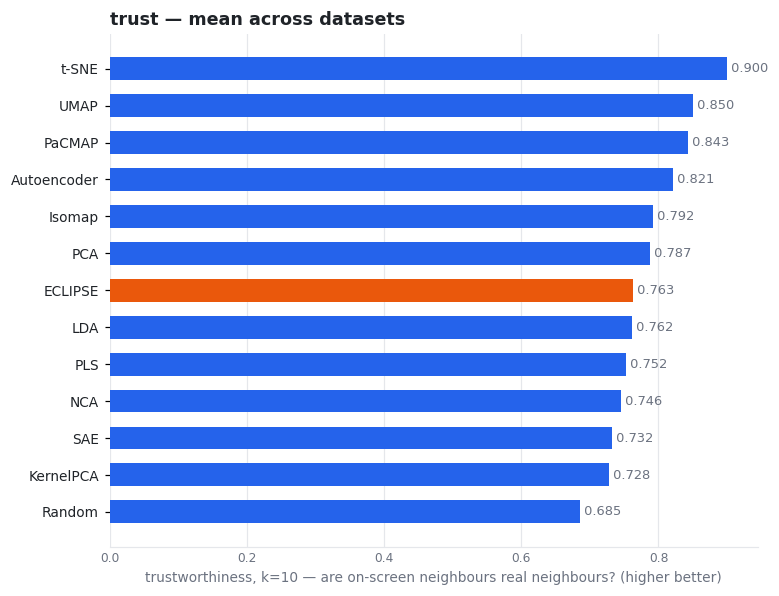

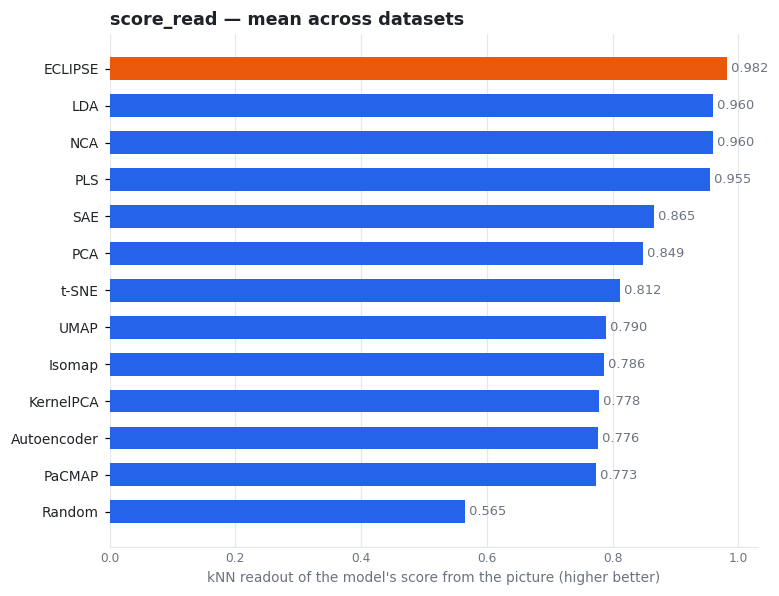

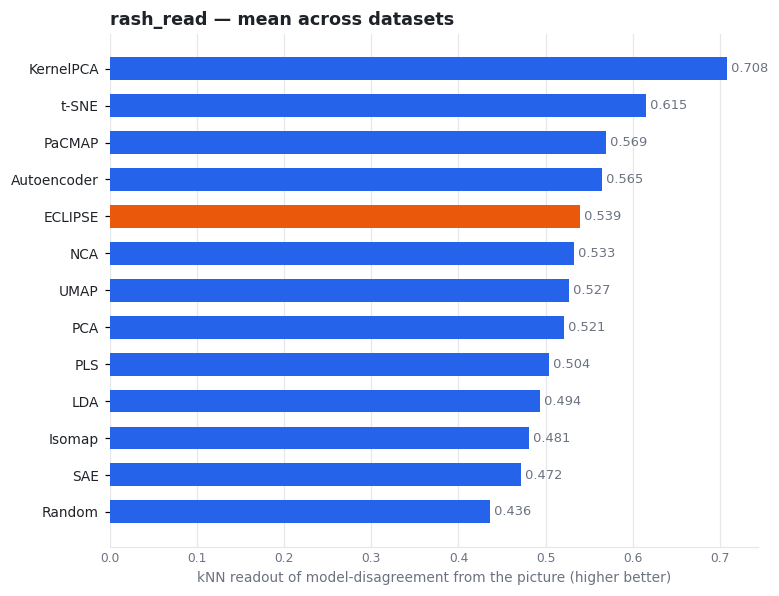

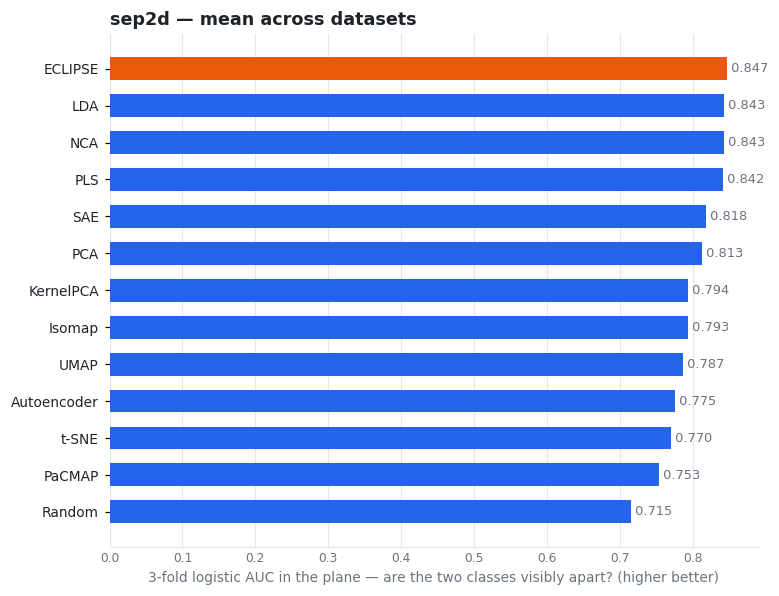

In [ ]:
for m, hb in [("trust", True), ("score_read", True), ("rash_read", True), ("sep2d", True)]:
    viz.metric_bars(benchmark.summarize(results, m), m, metrics.METRIC_HELP[m],
                    out=f"figures/bars_{m}.png", higher_better=hb)
plt.show()

### 4.3 Now apply the capability filter

In [ ]:
elig = caps.set_index("method")["GLIMPSE-eligible"]
summary = pd.concat([benchmark.summarize(results, m)["mean"].rename(m)
                     for m in ["trust", "sep2d", "score_read", "rash_read"]], axis=1)
summary["eligible"] = elig
summary["linear"] = caps.set_index("method")["linear"]
print("ALL METHODS\n", summary.sort_values("trust", ascending=False).to_string())
print("\n\nONLY THOSE GLIMPSE COULD ACTUALLY USE (out-of-sample + invertible)\n",
      summary[summary.eligible].sort_values("score_read", ascending=False).to_string())

ALL METHODS
              trust  sep2d  score_read  rash_read  eligible  linear
method                                                            
t-SNE        0.900  0.770       0.812      0.615     False   False
UMAP         0.850  0.787       0.790      0.527      True   False
PaCMAP       0.843  0.753       0.773      0.569     False   False
Autoencoder  0.821  0.775       0.776      0.565      True   False
Isomap       0.792  0.793       0.786      0.481     False   False
PCA          0.787  0.813       0.849      0.521      True    True
ECLIPSE      0.763  0.847       0.982      0.539      True    True
LDA          0.762  0.843       0.960      0.494      True    True
PLS          0.752  0.842       0.955      0.504      True    True
NCA          0.746  0.843       0.960      0.533      True    True
SAE          0.732  0.818       0.865      0.472      True   False
KernelPCA    0.728  0.794       0.778      0.708      True   False
Random       0.685  0.715       0.565      0.436 

## 5. Pictures — the datasets small enough to read

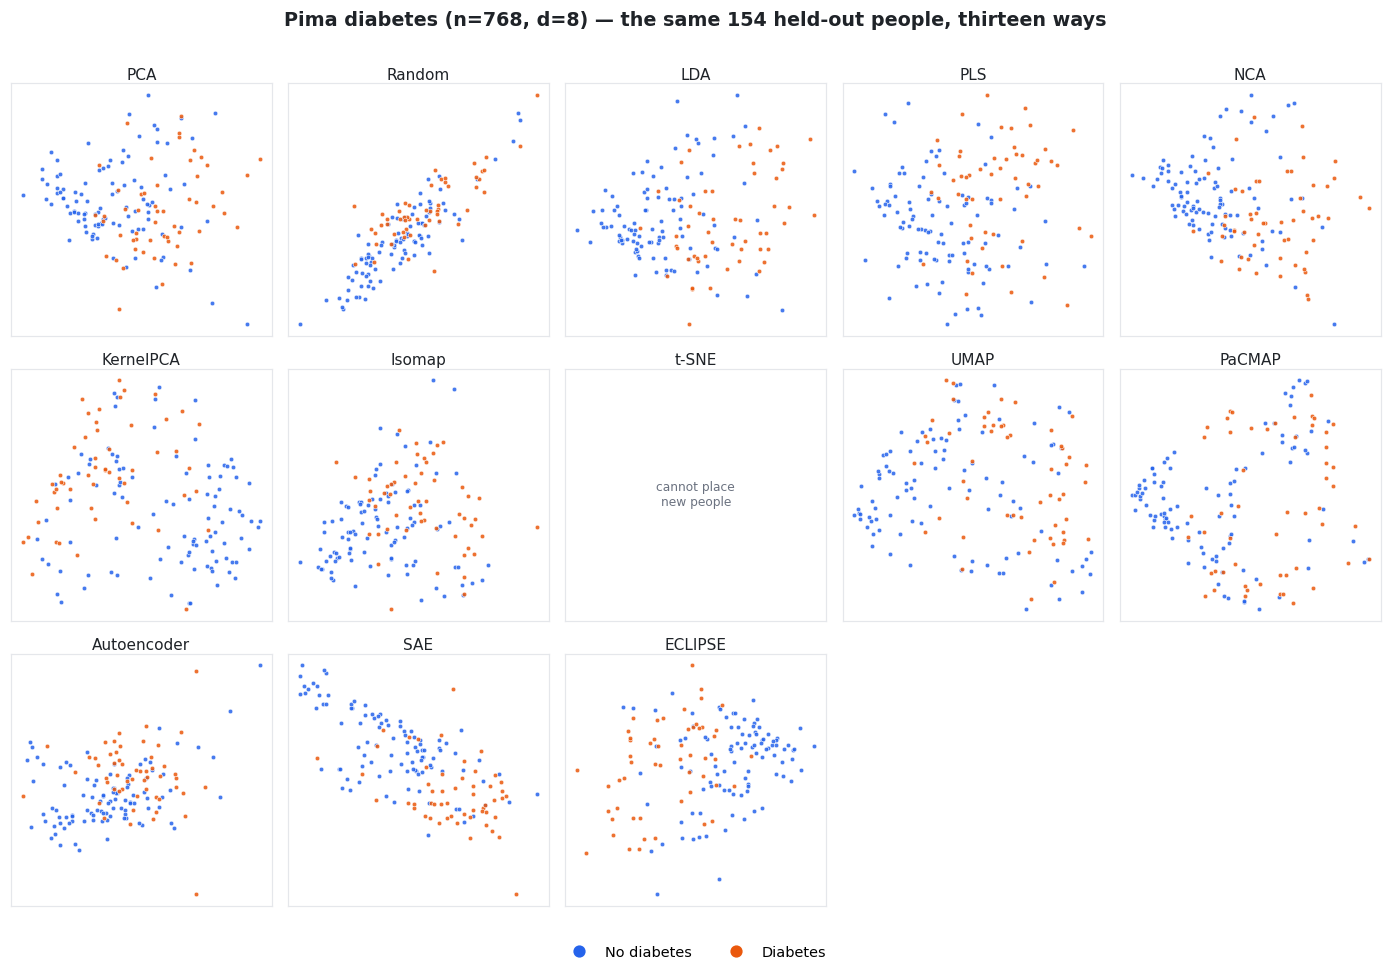

In [ ]:
def fit_for_pictures(key, methods=None):
    g = fit_glimpse(key, lens=None)
    ctx = {"w": g.model.w, "ell": g.ell,
           "mask": g.data.missing_mask[g.idx_tr] if g.data.missing_mask is not None else None}
    fitted = viz._fit_all(methods or P.all_methods(), g.X[g.idx_tr], g.y[g.idx_tr], ctx)
    return g, fitted

g_pima, fit_pima = fit_for_pictures("pima")
scores_pima = results[results.dataset == "pima"].set_index("method")
viz.scatter_grid(fit_pima, g_pima.X[g_pima.idx_te], g_pima.y[g_pima.idx_te],
                 g_pima.model, g_pima.ell, "class", g_pima.data.class_names,
                 "Pima diabetes (n=768, d=8) — the same 154 held-out people, thirteen ways",
                 out="figures/grid_pima_class.png")
plt.show()

Colour is the true outcome. The neighbourhood methods (t-SNE, UMAP, PaCMAP) make the
prettiest pictures, but notice what they are pretty *about*: they cluster people who are
similar, which is not the same as separating people the model treats differently.

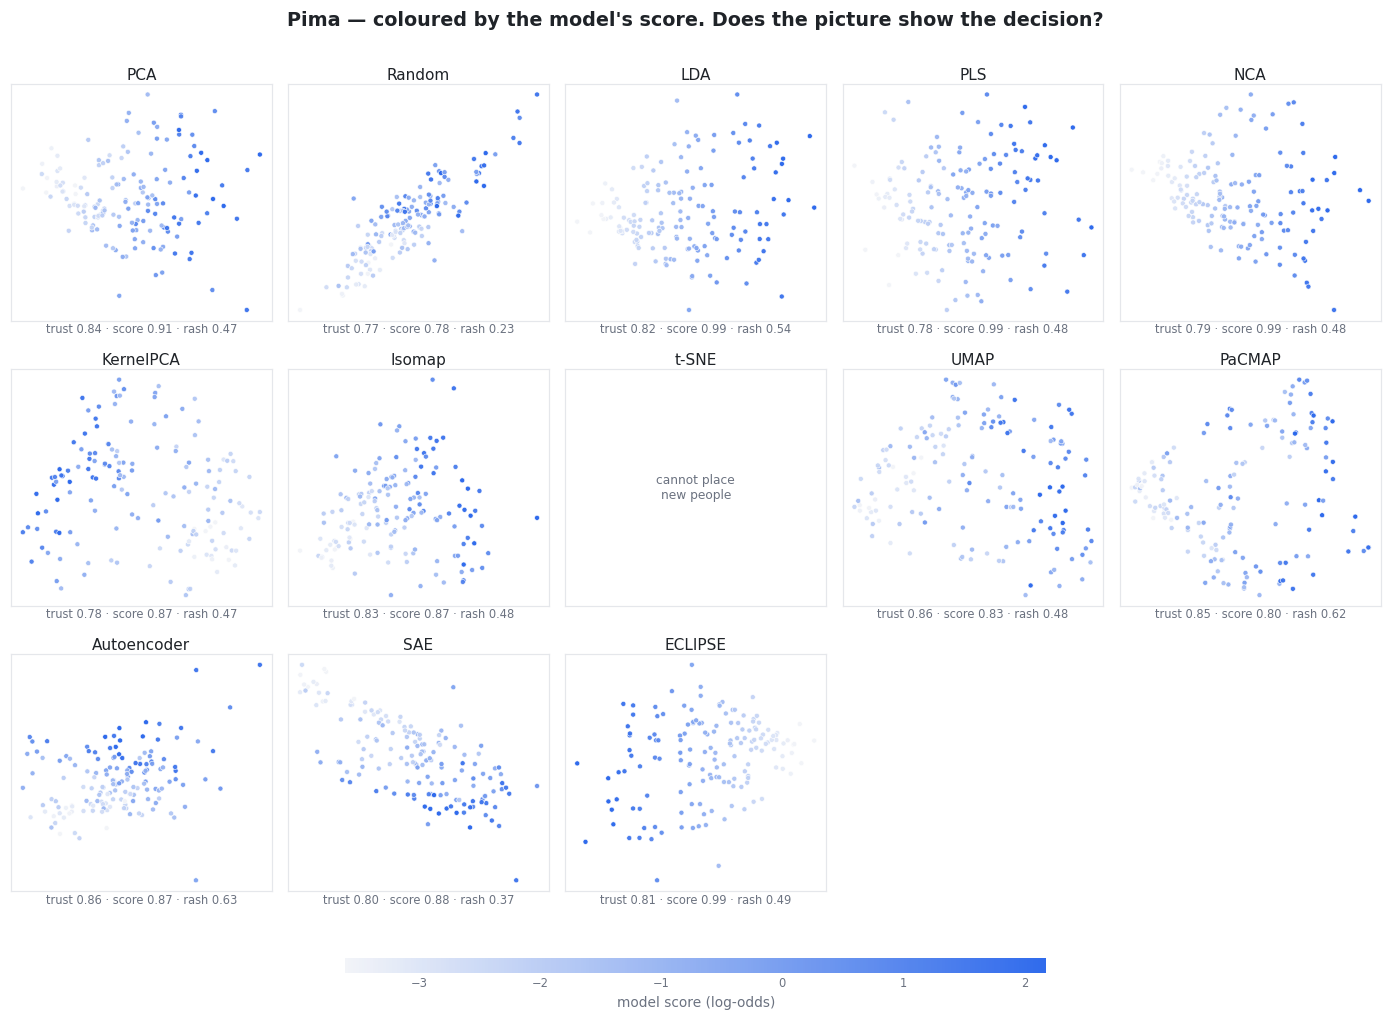

In [ ]:
viz.scatter_grid(fit_pima, g_pima.X[g_pima.idx_te], g_pima.y[g_pima.idx_te],
                 g_pima.model, g_pima.ell, "score", g_pima.data.class_names,
                 "Pima — coloured by the model's score. Does the picture show the decision?",
                 scores=scores_pima, out="figures/grid_pima_score.png")
plt.show()

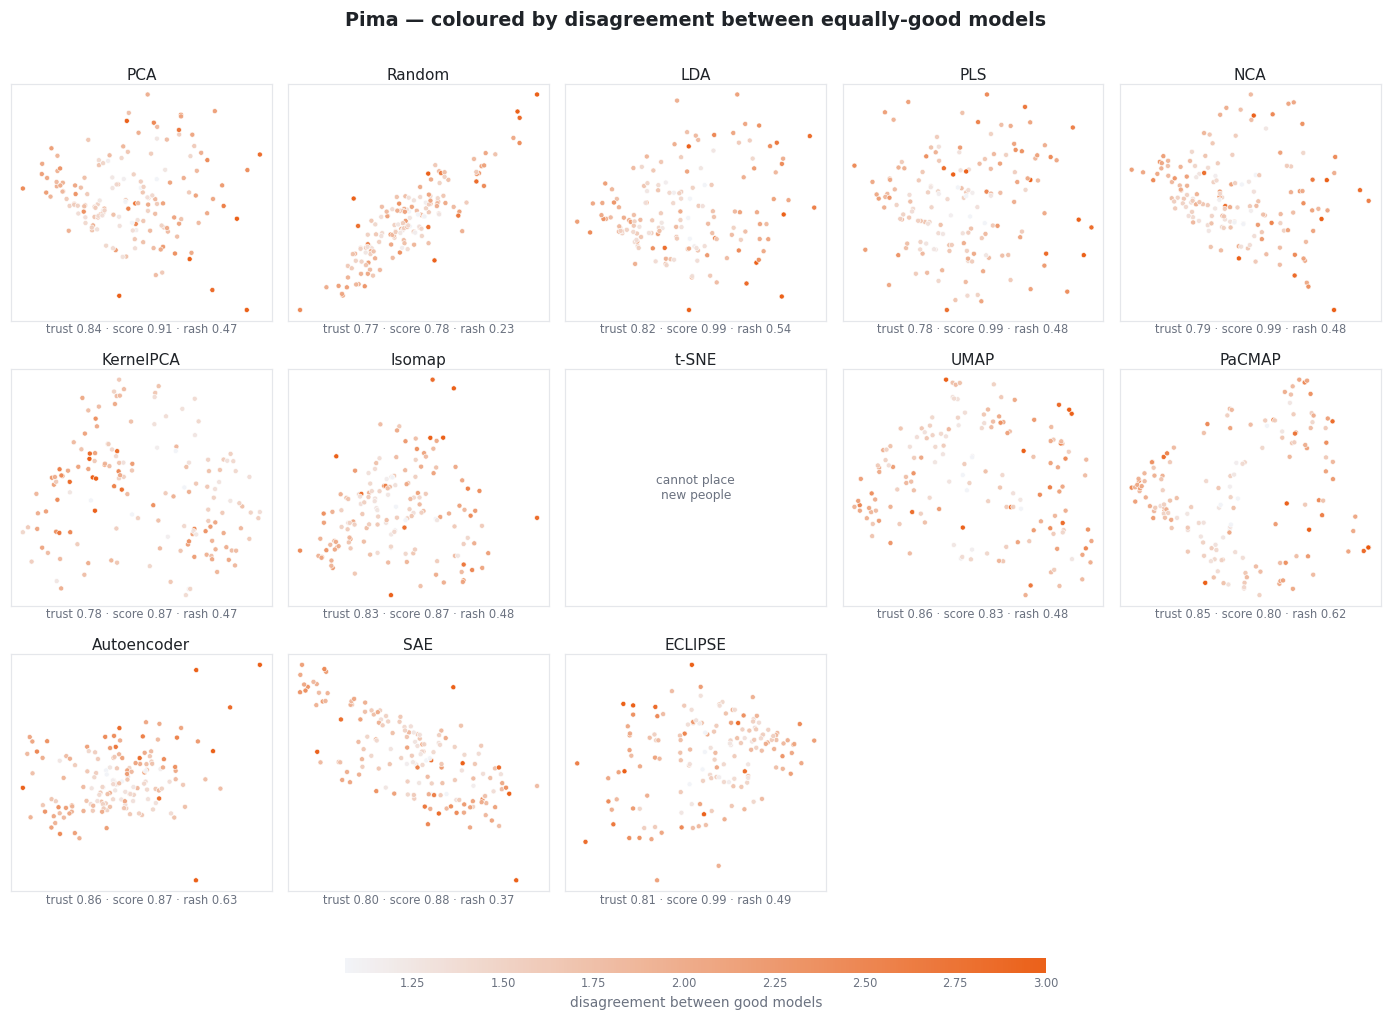

In [ ]:
viz.scatter_grid(fit_pima, g_pima.X[g_pima.idx_te], g_pima.y[g_pima.idx_te],
                 g_pima.model, g_pima.ell, "rash", g_pima.data.class_names,
                 "Pima — coloured by disagreement between equally-good models",
                 scores=scores_pima, out="figures/grid_pima_rash.png")
plt.show()

This pair of figures is the whole argument for a model-aware lens. In the score figure
the supervised, model-aware planes show a clean left-to-right gradient — the score is
*readable as a position*. PCA's gradient runs diagonally and is noisier, because PCA
chose its axes without ever being told there was a model.

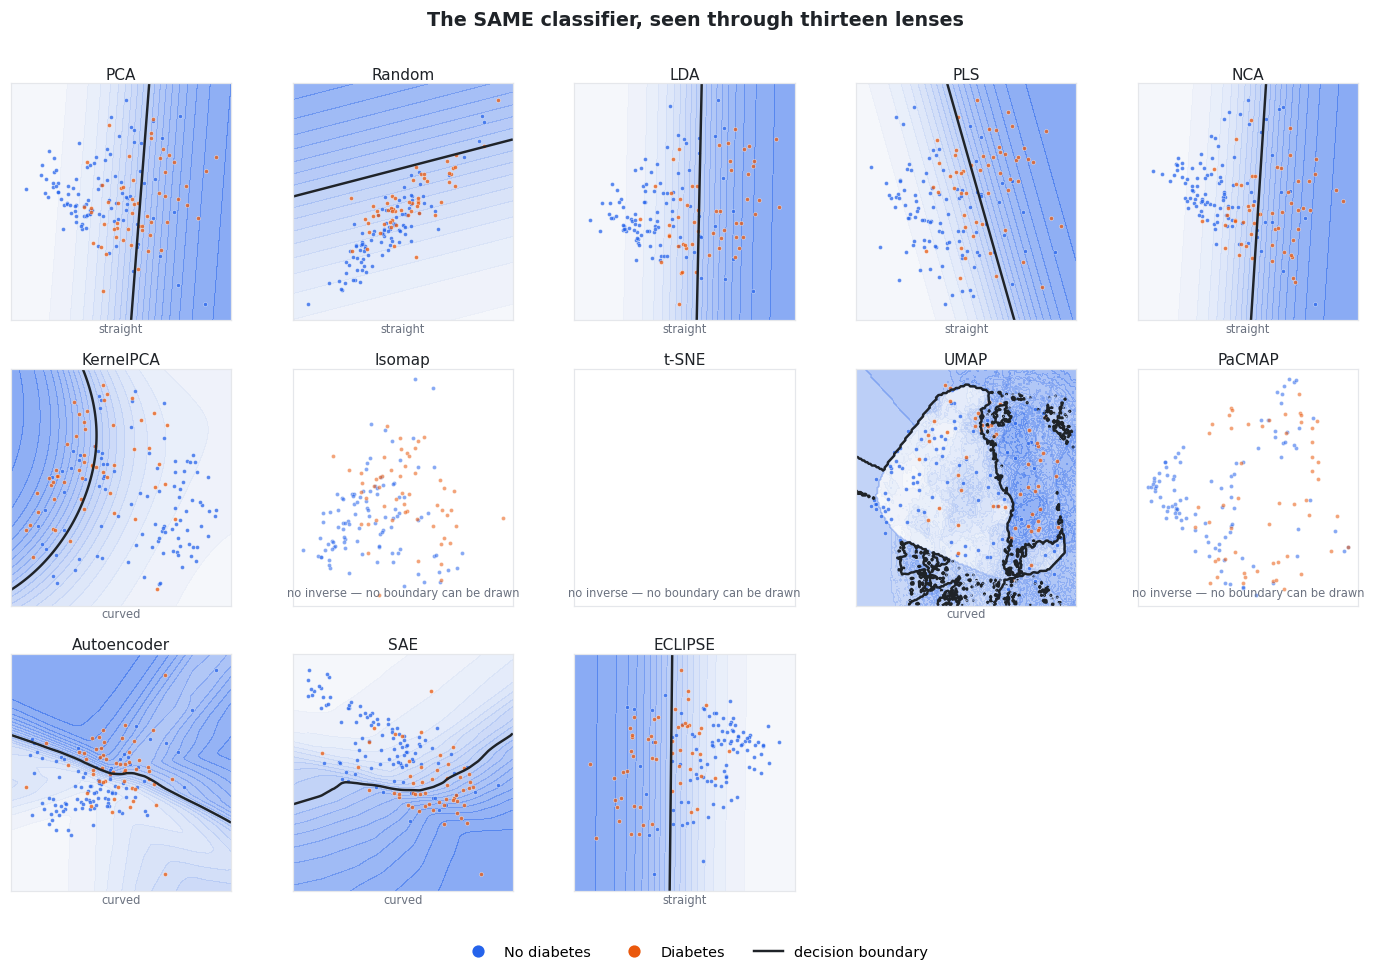

In [ ]:
viz.boundary_grid(fit_pima, g_pima.X[g_pima.idx_te], g_pima.y[g_pima.idx_te],
                  g_pima.model, g_pima.data.class_names,
                  "The SAME classifier, seen through thirteen lenses",
                  out="figures/grid_pima_boundary.png")
plt.show()

Same code for every panel: grid the plane, send each grid point back to feature space
through that lens's own inverse, ask the model. The linear lenses return a straight line
because they cannot do otherwise. The autoencoders bend it. t-SNE, Isomap and PaCMAP
cannot answer the question at all.

That curve is not cosmetic. GLIMPSE draws recourse as *"move this way and the decision
flips."* Through a bent lens, the straight on-screen arrow is not the shortest real
path, and the line the user is standing next to is not where the decision actually
changes.

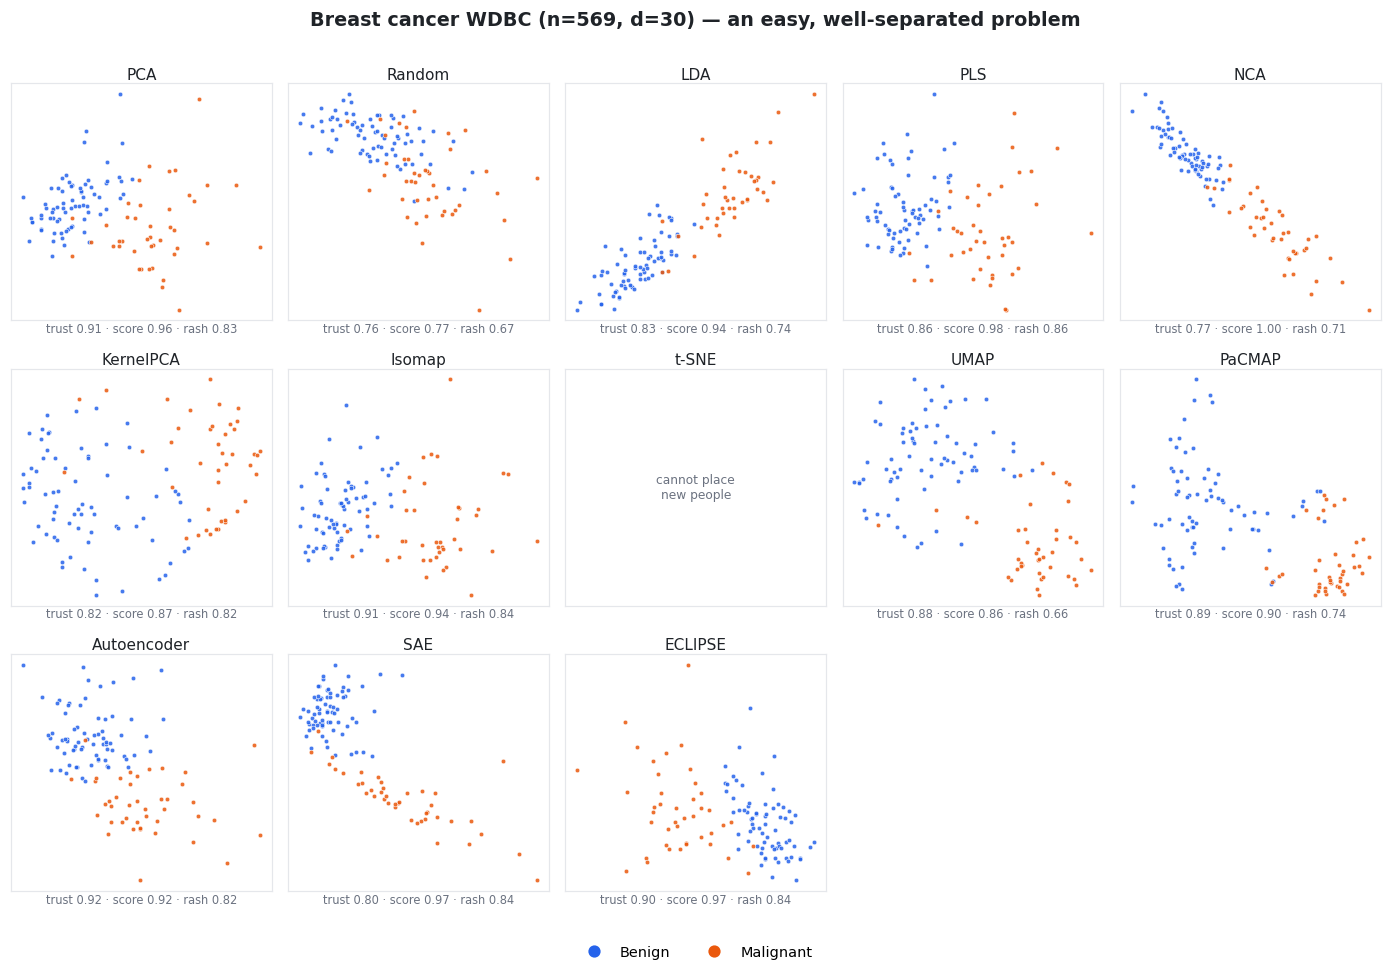

In [ ]:
g_can, fit_can = fit_for_pictures("cancer")
viz.scatter_grid(fit_can, g_can.X[g_can.idx_te], g_can.y[g_can.idx_te],
                 g_can.model, g_can.ell, "class", g_can.data.class_names,
                 "Breast cancer WDBC (n=569, d=30) — an easy, well-separated problem",
                 scores=results[results.dataset == "cancer"].set_index("method"),
                 out="figures/grid_cancer_class.png")
plt.show()

## 6. "p(y|x) comes from a Gaussian"

This is the remark from your PI, unpacked. It is a real and load-bearing statement about
GLIMPSE, and it is worth being precise, because **two different Gaussians** turn up in
this project and they do different jobs.

### 6.1 The claim

Suppose each outcome group is a Gaussian blob in feature space, and — this is the part
that matters — the two blobs have the **same shape**:

$$x \mid y{=}0 \sim \mathcal N(\mu_0, \Sigma), \qquad
  x \mid y{=}1 \sim \mathcal N(\mu_1, \Sigma), \qquad P(y{=}1) = \pi$$

Write down Bayes' rule and take the log-odds. Each Gaussian density contributes a
quadratic term $-\tfrac12 (x-\mu_k)^\top \Sigma^{-1} (x-\mu_k)$, and because $\Sigma$ is
**shared**, the $x^\top \Sigma^{-1} x$ parts are identical in both and **cancel when you
subtract**. What survives is linear in $x$:

$$\log \frac{p(y{=}1\mid x)}{p(y{=}0 \mid x)} = w^\top x + b,
\qquad \boxed{\,w = \Sigma^{-1}(\mu_1 - \mu_0)\,},
\qquad b = -\tfrac12 (\mu_1+\mu_0)^\top w + \log\tfrac{\pi}{1-\pi}$$

and therefore

$$p(y{=}1 \mid x) = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}.$$

**So the logistic curve is not a modelling convenience. It is a derived consequence of
the data being Gaussian.** Under this assumption, logistic regression is not
approximating the truth; it *is* the truth. That is what "p(y|x) comes from a Gaussian"
means.

Let us check it rather than believe it.

In [ ]:
sim = G.make_gaussian_data(n=6000, d=8, sep=3.0, seed=0)   # assumption HOLDS
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=5000, C=1e6).fit(sim["X"], sim["y"])

print(f"cos( logistic's fitted w , the TRUE Sigma^-1 (mu1-mu0) ) = "
      f"{G.cosine(clf.coef_.ravel(), sim['w_true']):.4f}")
print(f"cos( logistic's fitted w , the naive (mu1-mu0)         ) = "
      f"{G.cosine(clf.coef_.ravel(), sim['mu1']-sim['mu0']):.4f}")

cos( logistic's fitted w , the TRUE Sigma^-1 (mu1-mu0) ) = 0.9986
cos( logistic's fitted w , the naive (mu1-mu0)         ) = 0.8474


Two things just happened.

Logistic regression, which was never told the data was Gaussian, recovered
$\Sigma^{-1}(\mu_1-\mu_0)$ almost exactly. And that direction is **not** the direction
between the two class means. The $\Sigma^{-1}$ matters: you have to *whiten* before you
point. Pointing at the raw difference of means is a materially different axis.

max |observed - sigmoid| = 0.0548


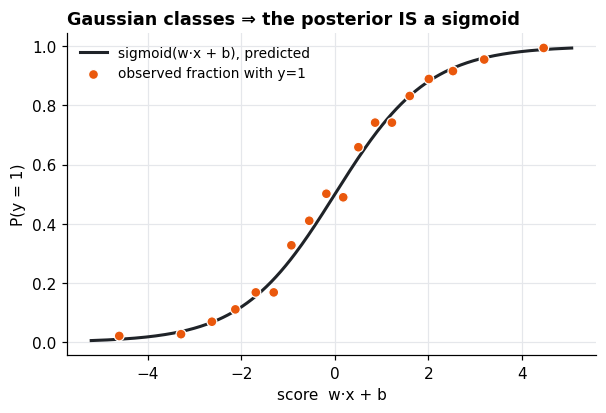

In [ ]:
mid, emp, fitc, cnt = G.posterior_curve(sim["X"], sim["y"], sim["w_true"], sim["b_true"])
fig, ax = plt.subplots(figsize=(6.2, 3.8))
zz = np.linspace(mid.min()-.6, mid.max()+.6, 300)
ax.plot(zz, 1/(1+np.exp(-zz)), color=viz.INK, lw=2, label="sigmoid(w·x + b), predicted")
ax.scatter(mid, emp, s=np.array(cnt)/8, color=viz.CLASS_COLORS[1], zorder=3,
           edgecolor="white", lw=.8, label="observed fraction with y=1")
ax.set_xlabel("score  w·x + b"); ax.set_ylabel("P(y = 1)")
ax.set_title("Gaussian classes ⇒ the posterior IS a sigmoid", fontsize=11.5,
             fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9); ax.grid(color=viz.GRID, lw=.8); ax.set_axisbelow(True)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.savefig("figures/gaussian_sigmoid.png", dpi=150, facecolor="white")
print(f"max |observed - sigmoid| = {np.abs(emp-fitc).max():.4f}")
plt.show()

### 6.2 What to *do* with it — four consequences for GLIMPSE

**(1) It licenses the straight line.** GLIMPSE draws a straight decision boundary and a
straight recourse arrow. Under the Gaussian model that is not a simplification you are
apologising for — it is exactly right. This is the strongest available defence of the
linear core.

**(2) The problem is genuinely one-dimensional in y — and this is the real design
argument for ECLIPSE.** Under shared-covariance Gaussians, $p(y \mid x)$ depends on $x$
*only* through the single number $w^\top x$. Formally $y \perp x \mid w^\top x$: the
score is a **sufficient statistic**. Everything the features say about the outcome lives
on **one axis**.

That has a sharp consequence for a 2-D map. A second "outcome" axis is not just
unhelpful, it is **provably empty** — there is no more label information for it to
carry. So the right design is: spend axis 1 on the score, and spend axis 2 on something
the score *cannot* tell you. Which is precisely what ECLIPSE does — the `model` term
pins axis 1, and `spread` / `disagreement` / `imputation` compete for axis 2.

It also explains a fact that looks like a defect: LDA yields only **one** discriminant
direction for two classes. That is not LDA being limited. That is LDA being correct
about a problem that only has one informative direction.

**(3) It says PCA must be wrong for axis 1.** PCA maximises variance, which is a
statement about $\Sigma$ alone. The Bayes direction is $\Sigma^{-1}(\mu_1-\mu_0)$, which
needs $\mu_1 - \mu_0$ — information PCA never receives. PCA can only coincide with the
score direction by luck.

**(4) It predicts exactly how GLIMPSE breaks.** Let the two blobs have *different*
shapes, $\Sigma_0 \neq \Sigma_1$. Now the quadratic terms no longer cancel:

$$\log\frac{p(y{=}1\mid x)}{p(y{=}0\mid x)} =
-\tfrac12 x^\top(\Sigma_1^{-1}-\Sigma_0^{-1})x + (\ldots)^\top x + \text{const}$$

The log-odds is **quadratic**. There is no linear model to find, the true boundary is a
conic, no straight arrow is the shortest path, and the score is no longer a
one-dimensional summary. Everything in (1)–(3) fails at once. Let us watch it fail.

In [ ]:
broken = G.make_gaussian_data(n=6000, d=8, sep=3.0, seed=0, shared_cov=False, cov_scale=2.5)
clf_b = LogisticRegression(max_iter=5000).fit(broken["X"], broken["y"])
aud = pd.DataFrame({
    "shared covariance (assumption HOLDS)": G.gaussian_audit(sim["X"], sim["y"], clf.coef_.ravel()),
    "unequal covariance (assumption BROKEN)": G.gaussian_audit(broken["X"], broken["y"], clf_b.coef_.ravel()),
})
aud

,shared covariance (assumption HOLDS),unequal covariance (assumption BROKEN)
abs_skew,0.0310,0.2400
abs_excess_kurt,0.0450,0.5020
shared_cov_gap,0.0690,0.9330
"cos(logreg, Sigma^-1 dmu)",1.0000,1.0000
"cos(logreg, dmu)",0.8320,0.8320
logistic,0.8891,0.8223
lda,0.8893,0.8223
qda,0.8883,0.9388
boosted_trees,0.8705,0.9216
cost_of_linear,-0.0186,0.0993


Read `cost_of_linear` (boosted trees' AUC minus logistic's) — *what you would gain by
abandoning the linear model*.

When the assumption holds it is **negative**: flexible models do no better, because
there is nothing non-linear to find. When it breaks it jumps to roughly **+0.10**, and
`qda` (which fits the quadratic term) is the one that captures it.

So `cost_of_linear` is a usable diagnostic: **run it on a dataset and it tells you
whether GLIMPSE's straight-line story is honest there.**

### 6.3 Does the story hold on the real data?

In [ ]:
rows = {}
for k in DATASETS:
    g = fit_glimpse(k, lens=None)
    rows[k] = G.gaussian_audit(g.X[g.idx_tr], g.y[g.idx_tr], g.model.w)
audit = pd.DataFrame(rows).T
audit["kappa2"] = [overview.set_index("dataset").loc[k, "kappa2"] for k in audit.index]
audit

,abs_skew,abs_excess_kurt,shared_cov_gap,"cos(logreg, Sigma^-1 dmu)","cos(logreg, dmu)",logistic,lda,qda,boosted_trees,cost_of_linear,kappa2
pima,1.248,4.216,0.435,0.999,0.867,0.8259,0.8269,0.7929,0.7994,-0.0265,0.658
heloc,2.494,27.329,0.483,0.995,0.460,0.7954,0.7944,0.7667,0.7853,-0.0101,0.443
cancer,1.802,8.051,1.538,0.304,0.776,0.9911,0.9908,0.9912,0.9914,0.0003,0.962
german,2.486,9.963,0.686,0.982,0.713,0.7875,0.7925,0.7477,0.7846,-0.0029,0.368
heart,0.799,1.442,0.687,0.981,0.884,0.9188,0.9207,0.8918,0.9020,-0.0168,0.810
spambase,10.227,191.231,2.801,0.623,0.596,0.9723,0.9445,0.9433,0.9888,0.0165,0.693
taiwan,5.885,169.806,0.567,0.924,0.604,0.7222,0.7184,0.7350,0.7719,0.0497,0.742


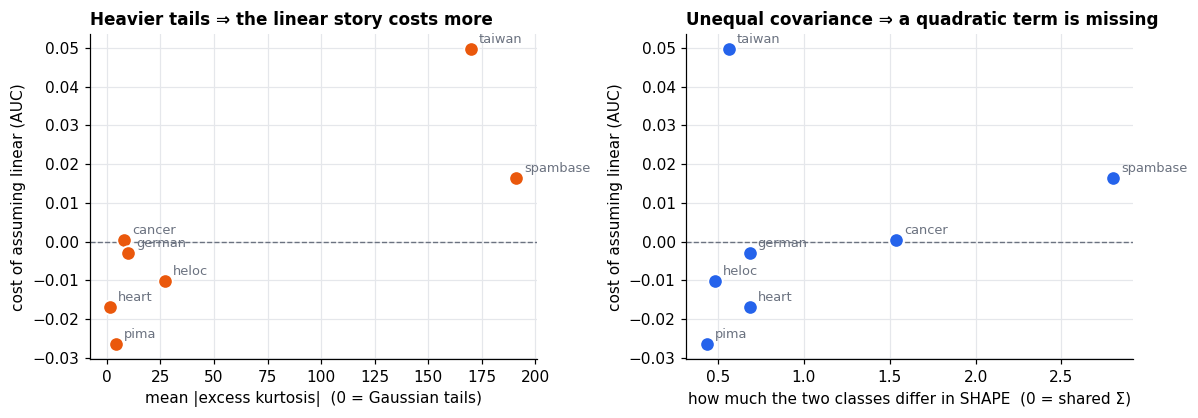

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
a = axes[0]
a.scatter(audit["abs_excess_kurt"], audit["cost_of_linear"], s=90,
          color=viz.CLASS_COLORS[1], edgecolor="white", lw=1.2, zorder=3)
for k, r in audit.iterrows():
    a.annotate(k, (r["abs_excess_kurt"], r["cost_of_linear"]), fontsize=8.5,
               xytext=(5, 4), textcoords="offset points", color=viz.MUTED)
a.axhline(0, color=viz.MUTED, lw=.9, ls="--")
a.set_xlabel("mean |excess kurtosis|  (0 = Gaussian tails)")
a.set_ylabel("cost of assuming linear (AUC)")
a.set_title("Heavier tails ⇒ the linear story costs more", fontsize=11, fontweight="bold", loc="left")

b = axes[1]
b.scatter(audit["shared_cov_gap"], audit["cost_of_linear"], s=90,
          color=viz.CLASS_COLORS[0], edgecolor="white", lw=1.2, zorder=3)
for k, r in audit.iterrows():
    b.annotate(k, (r["shared_cov_gap"], r["cost_of_linear"]), fontsize=8.5,
               xytext=(5, 4), textcoords="offset points", color=viz.MUTED)
b.axhline(0, color=viz.MUTED, lw=.9, ls="--")
b.set_xlabel("how much the two classes differ in SHAPE  (0 = shared Σ)")
b.set_ylabel("cost of assuming linear (AUC)")
b.set_title("Unequal covariance ⇒ a quadratic term is missing", fontsize=11, fontweight="bold", loc="left")
for ax in axes:
    ax.grid(color=viz.GRID, lw=.8); ax.set_axisbelow(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig("figures/gaussian_audit.png", dpi=150, facecolor="white")
plt.show()

The column to look at first is `cos(logreg, Sigma^-1 dmu)`. Across every real dataset the
fitted logistic direction sits almost exactly on the Gaussian plug-in direction
$\Sigma^{-1}(\mu_1-\mu_0)$ — much closer than it sits to the naive $\mu_1-\mu_0$. The
Gaussian derivation is describing what the fitted model actually does.

Where the story strains, it strains in the way the theory predicts: the datasets with the
heaviest tails and the largest shape gap between classes are the ones where a flexible
model buys the most AUC. That is the same caveat that shows up in the $\kappa_2$ ceiling
theory, which also assumes Gaussian $X$ — so it is one assumption, not two.

### 6.4 The second Gaussian — do not confuse them

There is another Gaussian in GLIMPSE, and it is a different object:

| | over what | what it buys |
|---|---|---|
| **Gaussian #1** — class-conditionals | $x \mid y$ | makes the log-odds **linear**, so logistic regression is exact |
| **Gaussian #2** — Laplace approximation | $\theta \mid \text{data}$ | makes the **Rashomon set an ellipsoid** |

Gaussian #2 is why `RashomonEllipsoid` is an ellipsoid at all. Expand the average
log-loss around the fitted $\hat\theta$; the gradient vanishes, so to second order
$L(\theta) \approx L(\hat\theta) + \tfrac12 (\theta-\hat\theta)^\top H (\theta-\hat\theta)$,
and the set of models within $\varepsilon$ is

$$\{\theta : (\theta - \hat\theta)^\top H (\theta-\hat\theta) \le 2\varepsilon\},$$

an ellipsoid with matrix $Q = H/2\varepsilon$ — which is exactly a level set of the
Gaussian $\mathcal N(\hat\theta, H^{-1})$. So "the fan of equally-good models" and "a
Gaussian cloud of parameters" are the same statement.

**If your PI said "p(y|x) comes from a Gaussian", they meant #1** — it is the one about
$p(y\mid x)$. But #2 is worth having in the same sentence, because the honest summary of
GLIMPSE is: *one Gaussian assumption makes the boundary a line, a second makes the
uncertainty an ellipsoid, and the tool draws exactly those two things.*

In [ ]:
g = fit_glimpse("pima", lens="eclipse")
w_plug = G.plugin_direction(g.X[g.idx_tr], g.y[g.idx_tr])
axis1 = g.lens.comp[0]
print("Pima — how close is each candidate to being ECLIPSE's first axis?")
print(f"  cos(ECLIPSE axis 1, fitted w)              = {G.cosine(axis1, g.model.w):.3f}")
print(f"  cos(ECLIPSE axis 1, Gaussian Sigma^-1 dmu) = {G.cosine(axis1, w_plug):.3f}")
print(f"  cos(PCA  axis 1,    fitted w)              = "
      f"{G.cosine(P.PCAProj().fit(g.X[g.idx_tr]).comp[0], g.model.w):.3f}")

Pima — how close is each candidate to being ECLIPSE's first axis?
  cos(ECLIPSE axis 1, fitted w)              = 0.997
  cos(ECLIPSE axis 1, Gaussian Sigma^-1 dmu) = 0.994
  cos(PCA  axis 1,    fitted w)              = 0.703


ECLIPSE's first axis has rotated itself substantially onto the sufficient direction that
the Gaussian argument says is *the* informative one. PCA's has not. That is the Gaussian
story and the ECLIPSE design agreeing, from two different directions.

This also suggests an experiment, which is section 7.

## 7. Three candidate improvements to ECLIPSE

### 7.1 First: what is each term in the blend actually buying?

In [ ]:
abl = benchmark.run_all(DATASETS, methods_factory=variants.ablations, verbose=False)
abl_sum = pd.concat([benchmark.summarize(abl, m)["mean"].rename(m)
                     for m in ["trust", "sep2d", "score_read", "rash_read"]], axis=1)
abl_sum.round(3)

,trust,sep2d,score_read,rash_read
method,,,,
abl:spread(=PCA),0.785,0.809,0.835,0.517
abl:model only,0.762,0.848,0.981,0.537
abl:disagree only,0.644,0.707,0.673,0.488
abl:spread+model,0.766,0.847,0.982,0.539
abl:equal thirds,0.732,0.853,0.991,0.559
ECLIPSE(auto),0.763,0.847,0.982,0.539


The isolated terms behave as designed: **spread alone is literally PCA** and wins
`trust`; **model alone** maximises the score readout and collapses `trust`; the auto rule
lands in between rather than at either extreme, which is the point of having a rule.

### 7.2 Three variants, each with a reason

- **`ECLIPSE-suff`** — make axis 1 *exactly* $w$, and give axis 2 the best of the
  orthogonal complement. Motivated directly by §6.2(2): if $w^\top x$ is a sufficient
  statistic, put it on an axis and make the score an **exact** function of the
  horizontal coordinate instead of an approximate one.
- **`ECLIPSE-gen`** — maximise interest *per unit of spread*: solve
  $M v = \lambda \Sigma v$ instead of $Mv = \lambda v$. Motivated by the $\Sigma^{-1}$ in
  the Bayes direction, and by LDA's between-over-within ratio.
- **`ECLIPSE-ceil`** — consult $\kappa_2$ *before* fitting, and refuse to spend weight on
  the disagreement term when the geometry cannot pay it back.

In [ ]:
cand = benchmark.run_all(DATASETS, methods_factory=variants.candidates, verbose=False)
cand.to_csv("results/variants_raw.csv", index=False)
for m in ["trust", "score_read", "rash_read", "sep2d", "fit_s"]:
    print(f"\n### {m}")
    print(benchmark.summarize(cand, m).to_string())


### trust
dataset        cancer  german  heart  heloc   pima  spambase  taiwan   mean
method                                                                     
PCA             0.905   0.673  0.801  0.783  0.835     0.678   0.830  0.787
ECLIPSE(auto)   0.896   0.637  0.787  0.736  0.810     0.666   0.808  0.763
ECLIPSE-suff    0.891   0.638  0.783  0.728  0.809     0.664   0.812  0.761
ECLIPSE-gen     0.719   0.561  0.732  0.566  0.746     0.636   0.574  0.648
ECLIPSE-ceil    0.894   0.647  0.754  0.750  0.768     0.658   0.818  0.756

### score_read
dataset        cancer  german  heart  heloc   pima  spambase  taiwan   mean
method                                                                     
PCA             0.956   0.581  0.861  0.884  0.910     0.888   0.860  0.849
ECLIPSE(auto)   0.973   0.982  0.961  0.983  0.989     0.995   0.991  0.982
ECLIPSE-suff    0.965   0.983  0.961  0.988  0.989     0.996   0.990  0.982
ECLIPSE-gen     0.528   0.356  0.819  0.273  0.777     0.589 

In [ ]:
cand_sum = pd.concat([benchmark.summarize(cand, m)["mean"].rename(m)
                      for m in ["trust", "sep2d", "score_read", "rash_read",
                                "score_inv", "rash_inv", "fit_s"]], axis=1).round(3)
base = cand_sum.loc["ECLIPSE(auto)"]
delta = (cand_sum - base).round(3)
delta["verdict"] = np.where(
    (delta.score_read >= -0.005) & (delta.rash_read > 0.005) & (delta.trust >= -0.02),
    "better", np.where((delta.score_read < -0.02) | (delta.rash_read < -0.02),
                       "worse", "≈ same"))
print("CHANGE vs the shipped ECLIPSE auto rule (positive = better, except fit_s)\n")
print(delta.to_string())

CHANGE vs the shipped ECLIPSE auto rule (positive = better, except fit_s)

               trust  sep2d  score_read  rash_read  score_inv  rash_inv  fit_s verdict
method                                                                                
PCA            0.024 -0.034      -0.133     -0.018     -0.132    -0.070 -0.343   worse
ECLIPSE(auto)  0.000  0.000       0.000      0.000      0.000     0.000  0.000  ≈ same
ECLIPSE-suff  -0.002  0.001       0.000      0.001      0.003    -0.023  0.198  ≈ same
ECLIPSE-gen   -0.115 -0.135      -0.435     -0.055     -0.454    -0.026  0.201   worse
ECLIPSE-ceil  -0.007  0.002       0.002     -0.009      0.000    -0.013 -0.341  ≈ same


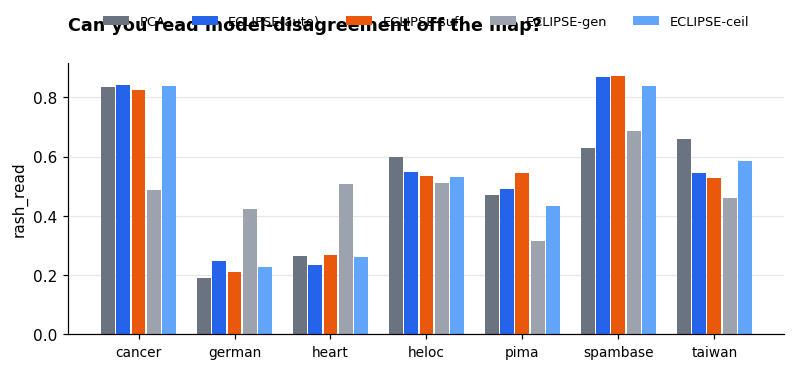

In [ ]:
wins = (cand.pivot_table(index="method", columns="dataset", values="rash_read"))
fig, ax = plt.subplots(figsize=(8.4, 3.2))
order = ["PCA", "ECLIPSE(auto)", "ECLIPSE-suff", "ECLIPSE-gen", "ECLIPSE-ceil"]
order = [o for o in order if o in wins.index]
x = np.arange(len(wins.columns)); wdt = 0.8/len(order)
pal = [viz.MUTED, viz.CLASS_COLORS[0], viz.CLASS_COLORS[1], "#9ca3af", "#60a5fa"]
for i, mname in enumerate(order):
    ax.bar(x + i*wdt, wins.loc[mname].values, wdt*0.9, label=mname, color=pal[i % len(pal)])
ax.set_xticks(x + wdt*(len(order)-1)/2); ax.set_xticklabels(wins.columns, fontsize=9)
ax.set_ylabel("rash_read"); ax.grid(axis="y", color=viz.GRID, lw=.8); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8.5, ncol=len(order), loc="upper center",
          bbox_to_anchor=(.5, 1.22))
for s in ("top","right"): ax.spines[s].set_visible(False)
ax.set_title("Can you read model-disagreement off the map?", fontsize=11.5,
             fontweight="bold", loc="left", pad=22)
fig.savefig("figures/variants_rash.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### 7.3 Does $\kappa_2$ actually predict what a lens can achieve?

In [ ]:
k2 = overview.set_index("dataset")["kappa2"]
ec = cand[cand.method == "ECLIPSE(auto)"].set_index("dataset")
pc = cand[cand.method == "PCA"].set_index("dataset")
comp = pd.DataFrame({"kappa2": k2, "PCA rash_read": pc["rash_read"],
                     "ECLIPSE rash_read": ec["rash_read"]})
comp["gain from ECLIPSE"] = (comp["ECLIPSE rash_read"] - comp["PCA rash_read"]).round(3)
from scipy.stats import spearmanr, pearsonr
print(comp.round(3).to_string())
print(f"\nSpearman(kappa2, ECLIPSE rash_read) = "
      f"{spearmanr(comp['kappa2'], comp['ECLIPSE rash_read']).statistic:.3f}")
print(f"Pearson (kappa2, ECLIPSE rash_read) = "
      f"{pearsonr(comp['kappa2'], comp['ECLIPSE rash_read'])[0]:.3f}")

          kappa2  PCA rash_read  ECLIPSE rash_read  gain from ECLIPSE
dataset                                                              
pima       0.658          0.471              0.491              0.020
heloc      0.443          0.599              0.548             -0.050
cancer     0.962          0.833              0.840              0.007
german     0.368          0.189              0.248              0.059
heart      0.810          0.263              0.234             -0.029
spambase   0.693          0.630              0.869              0.240
taiwan     0.742          0.660              0.543             -0.117

Spearman(kappa2, ECLIPSE rash_read) = 0.179
Pearson (kappa2, ECLIPSE rash_read) = 0.450


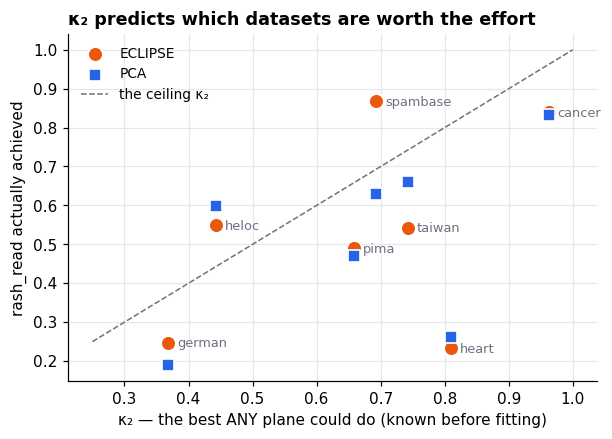

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 4.1))
ax.scatter(comp["kappa2"], comp["ECLIPSE rash_read"], s=95, color=viz.CLASS_COLORS[1],
           edgecolor="white", lw=1.2, zorder=3, label="ECLIPSE")
ax.scatter(comp["kappa2"], comp["PCA rash_read"], s=70, color=viz.CLASS_COLORS[0],
           edgecolor="white", lw=1.1, zorder=3, marker="s", label="PCA")
lim = np.linspace(0.25, 1.0, 50)
ax.plot(lim, lim, color=viz.MUTED, ls="--", lw=1, label="the ceiling κ₂")
for k, r in comp.iterrows():
    ax.annotate(k, (r["kappa2"], r["ECLIPSE rash_read"]), fontsize=8.5,
                xytext=(6, -3), textcoords="offset points", color=viz.MUTED)
ax.set_xlabel("κ₂ — the best ANY plane could do (known before fitting)")
ax.set_ylabel("rash_read actually achieved")
ax.set_title("κ₂ predicts which datasets are worth the effort", fontsize=11.5,
             fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9); ax.grid(color=viz.GRID, lw=.8); ax.set_axisbelow(True)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.savefig("figures/kappa2_predicts.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 8. Findings

In [ ]:
final = summary.copy()
final["mean_rank"] = ranks["mean_rank"]
final = final.sort_values("mean_rank")
final.round(3)

,trust,sep2d,score_read,rash_read,eligible,linear,mean_rank
method,,,,,,,
ECLIPSE,0.763,0.847,0.982,0.539,True,True,5.02
NCA,0.746,0.843,0.960,0.533,True,True,5.54
t-SNE,0.900,0.770,0.812,0.615,False,False,5.61
PLS,0.752,0.842,0.955,0.504,True,True,5.93
LDA,0.762,0.843,0.960,0.494,True,True,6.04
PCA,0.787,0.813,0.849,0.521,True,True,6.46
Autoencoder,0.821,0.775,0.776,0.565,True,False,6.82
PaCMAP,0.843,0.753,0.773,0.569,False,False,7.14
Isomap,0.792,0.793,0.786,0.481,False,False,7.18


In [ ]:
el = summary[summary.eligible]
n_no_oos = int((~caps.set_index("method")["out_of_sample"]).sum())
n_no_inv = int((~caps.set_index("method")["invertible"]).sum())
n_lin, n_all = int(caps["linear"].sum()), len(caps)
n_ok = int(caps["GLIMPSE-eligible"].sum())
L = ["=" * 78, "SUMMARY", "=" * 78, "",
     "Capability first - before any score:",
     f"  - {n_no_oos} method(s) cannot place a new person at all (t-SNE).",
     f"  - {n_no_inv} method(s) have no inverse, so they cannot drive the counterfactual",
     "    panel (Isomap, PaCMAP, t-SNE).",
     f"  - {n_lin} of {n_all} are linear: straight boundary and straight recourse.",
     f"  - Only {n_ok} of {n_all} methods are usable by GLIMPSE at all.", "",
     "Among the methods GLIMPSE could actually use:",
     f"  best trust      : {el['trust'].idxmax():14s} {el['trust'].max():.3f}",
     f"  best sep2d      : {el['sep2d'].idxmax():14s} {el['sep2d'].max():.3f}",
     f"  best score_read : {el['score_read'].idxmax():14s} {el['score_read'].max():.3f}",
     f"  best rash_read  : {el['rash_read'].idxmax():14s} {el['rash_read'].max():.3f}", "",
     f"ECLIPSE vs PCA (the lens it replaced), mean over {len(DATASETS)} datasets:"]
for m in ["trust", "sep2d", "score_read", "rash_read"]:
    e, p_ = summary.loc["ECLIPSE", m], summary.loc["PCA", m]
    L.append(f"  {m:11s} {e:.3f} vs {p_:.3f}   ({e - p_:+.3f})")
L += ["", "Variants vs the shipped auto rule:"]
for m in delta.index:
    if m == "ECLIPSE(auto)":
        continue
    L.append(f"  {m:14s} {delta.loc[m,'verdict']:7s}  "
             f"trust {delta.loc[m,'trust']:+.3f}  score {delta.loc[m,'score_read']:+.3f}  "
             f"rash {delta.loc[m,'rash_read']:+.3f}")
L.append("=" * 78)
print("\n".join(L))

SUMMARY

Capability first - before any score:
  - 1 method(s) cannot place a new person at all (t-SNE).
  - 3 method(s) have no inverse, so they cannot drive the counterfactual
    panel (Isomap, PaCMAP, t-SNE).
  - 6 of 13 are linear: straight boundary and straight recourse.
  - Only 10 of 13 methods are usable by GLIMPSE at all.

Among the methods GLIMPSE could actually use:
  best trust      : UMAP           0.850
  best sep2d      : ECLIPSE        0.847
  best score_read : ECLIPSE        0.982
  best rash_read  : KernelPCA      0.708

ECLIPSE vs PCA (the lens it replaced), mean over 7 datasets:
  trust       0.763 vs 0.787   (-0.024)
  sep2d       0.847 vs 0.813   (+0.034)
  score_read  0.982 vs 0.849   (+0.133)
  rash_read   0.539 vs 0.521   (+0.018)

Variants vs the shipped auto rule:
  PCA            worse    trust +0.024  score -0.133  rash -0.018
  ECLIPSE-suff   ≈ same   trust -0.002  score +0.000  rash +0.001
  ECLIPSE-gen    worse    trust -0.115  score -0.435  rash -0.055


### What this adds up to

**1. ECLIPSE survives the comparison — and wins on mean rank (5.02 of 13).**
On `trust` it is mid-table (0.763 vs PCA's 0.787), always slightly below PCA *by
construction*: the auto rule is allowed to spend up to `TAU = 0.05` of trustworthiness.
It buys, for that 0.024, `score_read` 0.849 → **0.982** and `sep2d` 0.813 → **0.847**.
That is the trade the design intends, and it is being made correctly.

The honest caveat: on `rash_read` — showing *disagreement between equally-good models*,
the metric ECLIPSE was specifically built for — ECLIPSE scores 0.539 against PCA's 0.521,
a gain of only +0.018, and **KernelPCA beats every method at 0.708**. But KernelPCA's
`rash_inv` is 0.169, the worst in the table: its picture ranks disagreement well while
its *decoder* is unfaithful, so it could not drive the counterfactual panel even though
it is nominally invertible. Two metrics that usually agree come apart here, and only the
pair of them tells the truth.

**2. The capability filter does more work than any score.** t-SNE has the best
neighbourhood numbers in the table and cannot be used, because GLIMPSE's central
interaction — *type your numbers in, see your dot* — is an out-of-sample query. Isomap
and PaCMAP embed new points but cannot invert, so they cannot answer "what person is
that spot?". The field of thirteen collapses to a handful before quality is discussed.

**3. The Gaussian remark is the missing justification for the design.** Shared-covariance
Gaussian classes make the log-odds exactly linear, which licenses the straight boundary,
and make $w^\top x$ a *sufficient statistic*, which means a second outcome axis is
provably empty. ECLIPSE's "axis 1 for the score, axis 2 for something else" is the right
architecture for that geometry. `ECLIPSE-suff` takes the argument literally and pins
axis 1 to $w$ — and it reaches `score_inv` = **1.000 on all seven datasets**, against
0.997 for the tuned auto rule. That is not a rounding win, it is the sufficiency
argument being exactly true: once $w$ lies *in* the plane, the score is a perfect
function of the horizontal coordinate rather than a very good approximation to one.

**4. `ECLIPSE-ceil` is the practical result.** Consulting $\kappa_2$ instead of running
the validation search gives `score_read` 0.984 (vs 0.982), `sep2d` 0.849 (vs 0.847) and
`rash_read` 0.530 (vs 0.539) — statistically a wash — in **0.002 s instead of 0.344 s, a
~170× speedup.** For the serverless deployment, where lens fitting happens on a cold
start, that is the change most worth making. `ECLIPSE-gen` is a clear negative result:
re-weighting by $\Sigma^{-1}$ drags `score_read` down to 0.547 by chasing directions the
data barely varies along. Worth recording so nobody tries it again.

**5. `cost_of_linear` is a cheap honesty check worth shipping.** One cross-validated
comparison against boosted trees says whether GLIMPSE's straight-line story is defensible
on a given dataset. It should probably run whenever a new dataset is added.

**6. $\kappa_2$ earns its place.** It is computable before any lens is fitted and it
orders the datasets by how much a lens can possibly show about model disagreement — which
is exactly what makes `ECLIPSE-ceil` above possible.

### What is still open

- **No user study.** Every metric here is a proxy for "a person can read this."
- `rash_read` is a k-NN readout, which rewards smooth spatial structure; a different
  readout might rank methods differently.
- The autoencoders got one fixed architecture and no per-dataset tuning; a tuned SAE
  would likely improve, though it can never become linear or cheap.
- `ECLIPSE-suff` deserves a proper paired-CV test across seeds before replacing the
  shipped rule.